In [2]:
# Install required libraries
!pip cache purge
!pip install torch torchvision timm pytorch-gradcam numpy matplotlib scikit-learn tqdm --no-cache-dir
# Verify installation
!pip show pytorch-gradcam

Files removed: 12
Name: pytorch-gradcam
Version: 0.2.1
Summary: A Simple pytorch implementation of GradCAM, and GradCAM++
Home-page: https://github.com/vickyliin/gradcam_plus_plus-pytorch
Author: vickyliin
Author-email: vickyliinn@gmail.com
License: 
Location: /usr/local/lib/python3.11/dist-packages
Requires: numpy, opencv-python
Required-by: 


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, SubsetRandomSampler
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import os
import time
from tqdm import tqdm
import timm

# Import pytorch-gradcam with fallback
try:
    from pytorch_grad_cam import GradCAM, LayerCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image
    print("pytorch_grad_cam modules imported successfully")
except ImportError:
    print("pytorch-gradcam not found. Attempting to install from GitHub...")
    !pip install git+https://github.com/jacobgil/pytorch-grad-cam.git --no-cache-dir
    from pytorch_grad_cam import GradCAM, LayerCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image
    print("pytorch_grad_cam modules imported successfully from GitHub")

%matplotlib inline

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

pytorch_grad_cam modules imported successfully
Using device: cuda


In [4]:
# Constants
IMAGE_SIZE = 224
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 50
NUM_CLASSES = 8
NUM_CLUSTERS = NUM_CLASSES
DATASET_PATH = '/kaggle/input/papaya/Augmented Dataset'
PATIENCE = 5
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.1  # For label smoothing
DROP_PATH_RATE = 0.1   # For stochastic depth (Swin Transformer only)
MIXUP_ALPHA = 0.2      # For Mixup augmentation

# Enhanced data augmentation
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(10),
        transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

# Mixup function
def mixup_data(x, y, alpha=0.2):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

# Load dataset
try:
    dataset = torchvision.datasets.ImageFolder(DATASET_PATH, transform=data_transforms['train'])
    class_names = dataset.classes
    print(f"Classes found: {class_names}")
    print(f"Dataset size: {len(dataset)}")
except Exception as e:
    print(f"Error loading dataset: {e}")
    raise

# Dataset splitting
def dataset_split(dataset, train_split=0.75, val_split=0.15, test_split=0.15):
    dataset_size = len(dataset)
    indices = list(range(dataset_size))
    np.random.seed(12)
    np.random.shuffle(indices)
    
    train_size = int(train_split * dataset_size)
    val_size = int(val_split * dataset_size)
    
    train_indices = indices[:train_size]
    val_indices = indices[train_size:train_size + val_size]
    test_indices = indices[train_size + val_size:]
    
    train_sampler = SubsetRandomSampler(train_indices)
    val_sampler = SubsetRandomSampler(val_indices)
    test_sampler = SubsetRandomSampler(test_indices)
    
    train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=0, pin_memory=True)
    val_loader = DataLoader(dataset, batch_size=BATCH_SIZE, sampler=val_sampler, num_workers=0, pin_memory=True)
    test_loader = DataLoader(dataset, batch_size=BATCH_SIZE, sampler=test_sampler, num_workers=0, pin_memory=True)
    
    print(f"Train size: {len(train_indices)}, Val size: {len(val_indices)}, Test size: {len(test_indices)}")
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = dataset_split(dataset)
# Cross-Attention Module
class CrossAttention(nn.Module):
    def __init__(self, dim, num_heads=8):
        super(CrossAttention, self).__init__()
        self.num_heads = num_heads
        self.scale = (dim // num_heads) ** -0.5
        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)
        self.dropout = nn.Dropout(0.4)  # Increased dropout for regularization

    def forward(self, x1, x2):
        B, C = x1.size()
        qkv1 = self.qkv(x1).reshape(B, self.num_heads, 3, C // self.num_heads).permute(2, 0, 1, 3)
        qkv2 = self.qkv(x2).reshape(B, self.num_heads, 3, C // self.num_heads).permute(2, 0, 1, 3)
        
        q1, k1, v1 = qkv1[0], qkv1[1], qkv1[2]
        q2, k2, v2 = qkv2[0], qkv2[1], qkv2[2]
        
        attn1 = (q1 @ k2.transpose(-2, -1)) * self.scale
        attn1 = attn1.softmax(dim=-1)
        out1 = (attn1 @ v2).transpose(1, 2).reshape(B, C)
        
        attn2 = (q2 @ k1.transpose(-2, -1)) * self.scale
        attn2 = attn2.softmax(dim=-1)
        out2 = (attn2 @ v1).transpose(1, 2).reshape(B, C)
        
        out = self.proj(out1 + out2)
        out = self.dropout(out)
        return out

Classes found: ['Antracnose', 'Bacterial Spot', 'Healthy Leaf', 'Leaf Curl', 'Mealybug', 'Mite Disease', 'Mosaic', 'Ring Spot']
Dataset size: 9342
Train size: 7006, Val size: 1401, Test size: 935


In [5]:
# Feature Extractor for K-means
class FeatureExtractor(nn.Module):
    def __init__(self, model):
        super(FeatureExtractor, self).__init__()
        self.model = model
        self.model.head = nn.Identity()  # Remove classification head
    
    def forward(self, x):
        feats = self.model(x)
        if feats.dim() > 2:
            feats = torch.mean(feats, dim=(2, 3))  # Global average pooling
        return feats

# Extract features for K-means
def extract_features(model, loader):
    model.eval()
    features = []
    labels = []
    images = []
    
    with torch.no_grad():
        for imgs, lbls in tqdm(loader, desc="Extracting features"):
            imgs = imgs.to(device)
            feats = model(imgs)
            features.append(feats.cpu().numpy())
            labels.append(lbls.numpy())
            images.append(imgs.cpu())
    features = np.concatenate(features, axis=0)
    labels = np.concatenate(labels, axis=0)
    images = torch.cat(images, dim=0)
    print(f"Extracted features shape: {features.shape}")
    return features, labels, images

# Apply K-means clustering
def apply_kmeans(features, num_clusters):
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)
    print(f"Scaled features shape: {features_scaled.shape}")
    
    n_components = min(50, features.shape[1])
    pca = PCA(n_components=n_components)
    features_reduced = pca.fit_transform(features_scaled)
    print(f"Reduced features shape: {features_reduced.shape}")
    
    kmeans = KMeans(n_clusters=num_clusters, random_state=12, n_init=10)
    clusters = kmeans.fit_predict(features_reduced)
    return clusters, kmeans, pca

# Visualize clusters
def visualize_clusters(images, clusters, labels, class_names, num_clusters, num_images_per_cluster=3):
    plt.figure(figsize=(15, 10))
    for cluster_idx in range(num_clusters):
        idxs = np.where(clusters == cluster_idx)[0]
        if len(idxs) == 0:
            print(f"Warning: Cluster {cluster_idx} is empty")
            continue
        cluster_images = images[idxs]
        cluster_labels = labels[idxs]
        
        for i in range(min(num_images_per_cluster, len(cluster_images))):
            plt.subplot(num_clusters, num_images_per_cluster, cluster_idx * num_images_per_cluster + i + 1)
            img = cluster_images[i].numpy().transpose((1, 2, 0))
            img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
            img = np.clip(img, 0, 1)
            plt.imshow(img)
            plt.title(f"Cluster {cluster_idx}\nLabel: {class_names[cluster_labels[i]]}")
            plt.axis('off')
    
    plt.tight_layout()
    plt.show()

In [6]:
# Model definitions
def get_swin_transformer(num_classes, device):
    model = timm.create_model('swin_base_patch4_window7_224', pretrained=True, num_classes=0, drop_path_rate=DROP_PATH_RATE)
    return model.to(device)

def get_ghostnet(num_classes, device):
    model = timm.create_model('ghostnet_100', pretrained=True, num_classes=0)  # Removed drop_path_rate
    return model.to(device)

# Ensemble model with Cross-Attention Fusion
class EnsembleModel(nn.Module):
    def __init__(self, swin_model, ghostnet_model, num_classes, feature_dim=1024):
        super(EnsembleModel, self).__init__()
        self.swin = swin_model
        self.ghostnet = ghostnet_model
        self.ghostnet_adaptor = nn.Linear(1280, 1024)  # Adapt GhostNet features to Swin dimension
        self.cross_attention = CrossAttention(feature_dim)
        self.dropout = nn.Dropout(0.6)  # Increased dropout for regularization
        self.fc = nn.Linear(feature_dim, num_classes)
        
    def forward(self, x):
        swin_features = self.swin(x)  # Shape: (batch_size, 1024)
        ghostnet_features = self.ghostnet(x)  # Shape: (batch_size, 1280)
        ghostnet_features = self.ghostnet_adaptor(ghostnet_features)  # Adapt to 1024
        fused = self.cross_attention(swin_features, ghostnet_features)
        fused = self.dropout(fused)
        output = self.fc(fused)
        return output

# Initialize models
swin_model = get_swin_transformer(NUM_CLASSES, device)
ghostnet_model = get_ghostnet(NUM_CLASSES, device)
model = EnsembleModel(swin_model, ghostnet_model, NUM_CLASSES).to(device)

# Freeze base layers
for param in swin_model.parameters():
    param.requires_grad = False
for param in ghostnet_model.parameters():
    param.requires_grad = False

# Unfreeze last layers
swin_stages = getattr(swin_model, 'layers', [])
if swin_stages and len(swin_stages) > 0:
    for param in swin_stages[-1].parameters():
        param.requires_grad = True
else:
    print("Warning: No 'layers' found in Swin Transformer. Unfreezing norm.")
    for param in swin_model.norm.parameters():
        param.requires_grad = True

ghostnet_blocks = getattr(ghostnet_model, 'blocks', [])
if ghostnet_blocks and len(ghostnet_blocks) > 0:
    for param in ghostnet_blocks[-1].parameters():
        param.requires_grad = True
else:
    print("Warning: No 'blocks' found in GhostNet. Unfreezing conv_head.")
    for param in ghostnet_model.conv_head.parameters():
        param.requires_grad = True

# Unfreeze ensemble layers
for param in model.fc.parameters():
    param.requires_grad = True
for param in model.cross_attention.parameters():
    param.requires_grad = True
for param in model.ghostnet_adaptor.parameters():
    param.requires_grad = True

# Loss and optimizer with class weights and label smoothing
from collections import Counter
class_counts = Counter(dataset.targets)
total_samples = len(dataset)
class_weights = torch.tensor([total_samples / (NUM_CLASSES * class_counts[i]) for i in range(NUM_CLASSES)], dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)
pseudo_criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = optim.AdamW([
    {'params': swin_model.parameters(), 'lr': 1e-6, 'weight_decay': WEIGHT_DECAY},
    {'params': ghostnet_model.parameters(), 'lr': 1e-6, 'weight_decay': WEIGHT_DECAY},
    {'params': model.fc.parameters(), 'lr': 1e-5, 'weight_decay': WEIGHT_DECAY},
    {'params': model.cross_attention.parameters(), 'lr': 1e-5, 'weight_decay': WEIGHT_DECAY},
    {'params': model.ghostnet_adaptor.parameters(), 'lr': 1e-5, 'weight_decay': WEIGHT_DECAY}
])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
# Loss and optimizer with class weights and label smoothing
from collections import Counter
class_counts = Counter(dataset.targets)
total_samples = len(dataset)
class_weights = torch.tensor([total_samples / (NUM_CLASSES * class_counts[i]) for i in range(NUM_CLASSES)], dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)
pseudo_criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = optim.AdamW([
    {'params': swin_model.parameters(), 'lr': 1e-6, 'weight_decay': WEIGHT_DECAY},
    {'params': ghostnet_model.parameters(), 'lr': 1e-6, 'weight_decay': WEIGHT_DECAY},
    {'params': model.fc.parameters(), 'lr': 1e-5, 'weight_decay': WEIGHT_DECAY},
    {'params': model.cross_attention.parameters(), 'lr': 1e-5, 'weight_decay': WEIGHT_DECAY},
    {'params': model.ghostnet_adaptor.parameters(), 'lr': 1e-5, 'weight_decay': WEIGHT_DECAY}
])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

Extracting features: 100%|██████████| 219/219 [03:01<00:00,  1.21it/s]


Extracted features shape: (7006, 7)
Scaled features shape: (7006, 7)
Reduced features shape: (7006, 7)


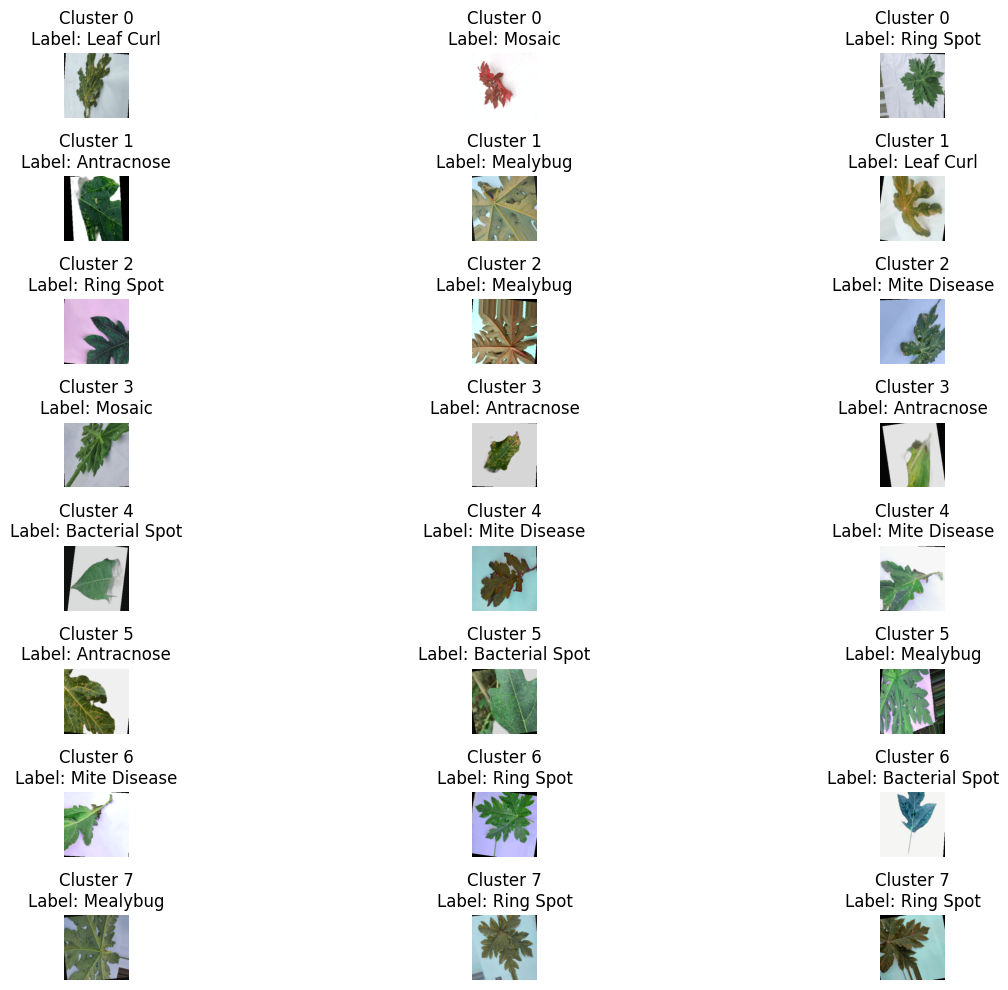

Epoch 1/50: 100%|██████████| 219/219 [03:22<00:00,  1.08batch/s, loss=2.53, accuracy=0.271, pseudo_acc=0.141]


219/219 ━━━━━━━━━━━━━━━━━━━━ 240s 1s/step - accuracy: 0.2708 - loss: 2.5349 - val_accuracy: 0.6338 - val_loss: 1.5665


Epoch 2/50: 100%|██████████| 219/219 [03:21<00:00,  1.09batch/s, loss=2.19, accuracy=0.406, pseudo_acc=0.13] 


219/219 ━━━━━━━━━━━━━━━━━━━━ 238s 1s/step - accuracy: 0.4058 - loss: 2.1939 - val_accuracy: 0.8401 - val_loss: 1.1600


Epoch 3/50: 100%|██████████| 219/219 [03:22<00:00,  1.08batch/s, loss=2.03, accuracy=0.479, pseudo_acc=0.126]


...

Epoch 19/50: 100%|██████████| 219/219 [03:21<00:00,  1.08batch/s, loss=1.74, accuracy=0.505, pseudo_acc=0.127]


219/219 ━━━━━━━━━━━━━━━━━━━━ 238s 1s/step - accuracy: 0.5050 - loss: 1.7414 - val_accuracy: 0.9836 - val_loss: 0.6643


Epoch 20/50: 100%|██████████| 219/219 [03:21<00:00,  1.09batch/s, loss=1.74, accuracy=0.538, pseudo_acc=0.126]


219/219 ━━━━━━━━━━━━━━━━━━━━ 237s 1s/step - accuracy: 0.5381 - loss: 1.7416 - val_accuracy: 0.9836 - val_loss: 0.6649


Epoch 21/50:  33%|███▎      | 72/219 [01:06<02:16,  1.08batch/s, loss=1.75, accuracy=0.642, pseudo_acc=0.123]


In [ ]:
# K-means clustering for pseudo-supervision
feature_extractor = FeatureExtractor(get_swin_transformer(NUM_CLASSES, device)).to(device)
features, labels, images = extract_features(feature_extractor, train_loader)
clusters, kmeans, pca = apply_kmeans(features, NUM_CLUSTERS)
visualize_clusters(images, clusters, labels, class_names, NUM_CLUSTERS)

# Pseudo-labeling
pseudo_labels = torch.tensor(clusters, dtype=torch.long).to(device)

# Training loop with pseudo-supervision and Mixup
def train_model(model, train_loader, val_loader, criterion, pseudo_criterion, optimizer, num_epochs, patience=PATIENCE):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None
    
    for epoch in range(num_epochs):
        start_time = time.time()
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        pseudo_correct = 0
        
        train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}', unit='batch')
        for batch_idx, (images, labels) in enumerate(train_pbar):
            images, labels = images.to(device), labels.to(device)
            
            # Apply Mixup
            images, labels_a, labels_b, lam = mixup_data(images, labels, MIXUP_ALPHA)
            
            optimizer.zero_grad()
            outputs = model(images)
            
            # Supervised loss with Mixup
            loss = lam * criterion(outputs, labels_a) + (1 - lam) * criterion(outputs, labels_b)
            
            # Pseudo-supervision loss
            batch_start = batch_idx * BATCH_SIZE
            batch_end = min(batch_start + BATCH_SIZE, len(pseudo_labels))
            batch_pseudo_labels = pseudo_labels[batch_start:batch_end]
            if batch_pseudo_labels.size(0) == outputs.size(0):
                pseudo_loss = pseudo_criterion(outputs, batch_pseudo_labels)
                loss = loss + 0.3 * pseudo_loss  # Weight pseudo-loss
            else:
                print(f"Warning: Pseudo-label size mismatch at batch {batch_idx}")
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient clipping
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels_a).sum().item()  # Accuracy based on primary labels
            pseudo_correct += (predicted == batch_pseudo_labels).sum().item() if batch_pseudo_labels.size(0) == outputs.size(0) else 0
            
            train_pbar.set_postfix({
                'loss': running_loss / total,
                'accuracy': correct / total,
                'pseudo_acc': pseudo_correct / total if total > 0 else 0
            })
        
        train_loss = running_loss / total
        train_acc = correct / total
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        val_loss = val_loss / total
        val_acc = correct / total
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        scheduler.step(val_loss)
        
        epoch_time = time.time() - start_time
        steps_per_epoch = len(train_loader)
        time_per_step = epoch_time / steps_per_epoch
        
        print(f"{steps_per_epoch}/{steps_per_epoch} ━━━━━━━━━━━━━━━━━━━━ {int(epoch_time)}s {int(time_per_step)}s/step - accuracy: {train_acc:.4f} - loss: {train_loss:.4f} - val_accuracy: {val_acc:.4f} - val_loss: {val_loss:.4f}")
        
        # # Early stopping
        # if val_loss < best_val_loss:
        #     best_val_loss = val_loss
        #     best_model_state = model.state_dict()
        #     patience_counter = 0
        #     torch.save(best_model_state, '/kaggle/working/best_checkpoint.pt')
        # else:
        #     patience_counter += 1
        #     if patience_counter >= patience:
        #         print(f"Early stopping at epoch {epoch+1}")
        #         model.load_state_dict(best_model_state)
        #         break
        
        torch.save(model.state_dict(), '/kaggle/working/checkpoint.pt')
    
    return history

# Train the model
history = train_model(model, train_loader, val_loader, criterion, pseudo_criterion, optimizer, EPOCHS)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, SubsetRandomSampler
import numpy as np
from sklearn.metrics import accuracy_score
import timm
from tqdm import tqdm
import os

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Constants
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 8  # Updated for 8 classes
EPOCHS = 10  # Reduced for faster execution; increase if needed
PATIENCE = 5
WEIGHT_DECAY = 1e-4
DATASET_PATH = '/kaggle/input/papaya/Augmented Dataset'

# Data transforms
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(10),
        transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

# Load dataset
try:
    dataset = torchvision.datasets.ImageFolder(DATASET_PATH, transform=data_transforms['train'])
    class_names = dataset.classes
    print(f"Classes found: {class_names}")
    print(f"Dataset size: {len(dataset)}")
except Exception as e:
    print(f"Error loading dataset: {e}")
    raise

# Dataset splitting (75/15/15)
def dataset_split(dataset, train_split=0.75, val_split=0.15, test_split=0.15):
    dataset_size = len(dataset)
    indices = list(range(dataset_size))
    np.random.seed(12)
    np.random.shuffle(indices)
    
    train_size = int(train_split * dataset_size)
    val_size = int(val_split * dataset_size)
    
    train_indices = indices[:train_size]
    val_indices = indices[train_size:train_size + val_size]
    test_indices = indices[train_size + val_size:]
    
    train_sampler = SubsetRandomSampler(train_indices)
    val_sampler = SubsetRandomSampler(val_indices)
    test_sampler = SubsetRandomSampler(test_indices)
    
    train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=0, pin_memory=True)
    val_loader = DataLoader(dataset, batch_size=BATCH_SIZE, sampler=val_sampler, num_workers=0, pin_memory=True)
    test_loader = DataLoader(dataset, batch_size=BATCH_SIZE, sampler=test_sampler, num_workers=0, pin_memory=True)
    
    print(f"Train size: {len(train_indices)}, Val size: {len(val_indices)}, Test size: {len(test_indices)}")
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = dataset_split(dataset)

# Cross-Attention Module
class CrossAttention(nn.Module):
    def __init__(self, dim, num_heads=8):
        super(CrossAttention, self).__init__()
        self.num_heads = num_heads
        self.scale = (dim // num_heads) ** -0.5
        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)
        self.dropout = nn.Dropout(0.4)

    def forward(self, x1, x2):
        B, C = x1.size()
        qkv1 = self.qkv(x1).reshape(B, self.num_heads, 3, C // self.num_heads).permute(2, 0, 1, 3)
        qkv2 = self.qkv(x2).reshape(B, self.num_heads, 3, C // self.num_heads).permute(2, 0, 1, 3)
        
        q1, k1, v1 = qkv1[0], qkv1[1], qkv1[2]
        q2, k2, v2 = qkv2[0], qkv2[1], qkv2[2]
        
        attn1 = (q1 @ k2.transpose(-2, -1)) * self.scale
        attn1 = attn1.softmax(dim=-1)
        out1 = (attn1 @ v2).transpose(1, 2).reshape(B, C)
        
        attn2 = (q2 @ k1.transpose(-2, -1)) * self.scale
        attn2 = attn2.softmax(dim=-1)
        out2 = (attn2 @ v1).transpose(1, 2).reshape(B, C)
        
        out = self.proj(out1 + out2)
        out = self.dropout(out)
        return out

# Model definitions
def get_swin_transformer(num_classes, device):
    model = timm.create_model('swin_base_patch4_window7_224', pretrained=True, num_classes=0, drop_path_rate=0.1)
    return model.to(device)

def get_ghostnet(num_classes, device):
    model = timm.create_model('ghostnet_100', pretrained=True, num_classes=0)
    return model.to(device)

# Ensemble model
class EnsembleModel(nn.Module):
    def __init__(self, swin_model, ghostnet_model, num_classes, feature_dim=1024):
        super(EnsembleModel, self).__init__()
        self.swin = swin_model
        self.ghostnet = ghostnet_model
        self.ghostnet_adaptor = nn.Linear(1280, 1024)
        self.cross_attention = CrossAttention(feature_dim)
        self.dropout = nn.Dropout(0.6)
        self.fc = nn.Linear(feature_dim, num_classes)
        
    def forward(self, x):
        swin_features = self.swin(x)
        ghostnet_features = self.ghostnet(x)
        ghostnet_features = self.ghostnet_adaptor(ghostnet_features)
        fused = self.cross_attention(swin_features, ghostnet_features)
        fused = self.dropout(fused)
        output = self.fc(fused)
        return output

# Initialize model
swin_model = get_swin_transformer(NUM_CLASSES, device)
ghostnet_model = get_ghostnet(NUM_CLASSES, device)
model = EnsembleModel(swin_model, ghostnet_model, NUM_CLASSES).to(device)

# Freeze base layers
for param in swin_model.parameters():
    param.requires_grad = False
for param in ghostnet_model.parameters():
    param.requires_grad = False

# Unfreeze last layers
swin_stages = getattr(swin_model, 'layers', [])
if swin_stages and len(swin_stages) > 0:
    for param in swin_stages[-1].parameters():
        param.requires_grad = True
else:
    for param in swin_model.norm.parameters():
        param.requires_grad = True

ghostnet_blocks = getattr(ghostnet_model, 'blocks', [])
if ghostnet_blocks and len(ghostnet_blocks) > 0:
    for param in ghostnet_blocks[-1].parameters():
        param.requires_grad = True
else:
    for param in ghostnet_model.conv_head.parameters():
        param.requires_grad = True

# Unfreeze ensemble layers
for param in model.fc.parameters():
    param.requires_grad = True
for param in model.cross_attention.parameters():
    param.requires_grad = True
for param in model.ghostnet_adaptor.parameters():
    param.requires_grad = True

# Loss and optimizer
from collections import Counter
class_counts = Counter(dataset.targets)
total_samples = len(dataset)
class_weights = torch.tensor([total_samples / (NUM_CLASSES * class_counts[i]) for i in range(NUM_CLASSES)], dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW([
    {'params': swin_model.parameters(), 'lr': 1e-6, 'weight_decay': WEIGHT_DECAY},
    {'params': ghostnet_model.parameters(), 'lr': 1e-6, 'weight_decay': WEIGHT_DECAY},
    {'params': model.fc.parameters(), 'lr': 1e-5, 'weight_decay': WEIGHT_DECAY},
    {'params': model.cross_attention.parameters(), 'lr': 1e-5, 'weight_decay': WEIGHT_DECAY},
    {'params': model.ghostnet_adaptor.parameters(), 'lr': 1e-5, 'weight_decay': WEIGHT_DECAY}
])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Training loop
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, patience):
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}', unit='batch')
        for images, labels in train_pbar:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            train_pbar.set_postfix({'loss': running_loss / total, 'accuracy': correct / total})
        
        train_loss = running_loss / total
        train_acc = correct / total
        
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        val_loss = val_loss / total
        val_acc = correct / total
        
        scheduler.step(val_loss)
        
        print(f"Epoch {epoch+1}/{num_epochs} - Train Acc: {train_acc:.4f}, Train Loss: {train_loss:.4f}, Val Acc: {val_acc:.4f}, Val Loss: {val_loss:.4f}")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict()
            patience_counter = 0
            torch.save(best_model_state, '/kaggle/working/best_checkpoint.pt')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                model.load_state_dict(best_model_state)
                break

# Train the model
train_model(model, train_loader, val_loader, criterion, optimizer, EPOCHS, PATIENCE)

# Load best checkpoint
try:
    model.load_state_dict(torch.load('/kaggle/working/best_checkpoint.pt'))
    print("Loaded best checkpoint successfully")
except Exception as e:
    print(f"Error loading checkpoint: {e}")
    raise

# Evaluate test accuracy
def evaluate_test_accuracy(model, test_loader):
    model.eval()
    y_true = []
    y_pred = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
    
    accuracy = accuracy_score(y_true, y_pred)
    print(f"✅ Test Accuracy: {accuracy:.4f}")
    return accuracy

test_accuracy = evaluate_test_accuracy(model, test_loader)

In [ ]:
import matplotlib.pyplot as plt

# Accuracy and Loss values from your log
train_acc = [0.4306, 0.6727, 0.8002, 0.8650, 0.9051, 0.9253, 0.9402, 0.9513, 0.9548, 0.9643]
val_acc = [0.6324, 0.8216, 0.8822, 0.9158, 0.9293, 0.9600, 0.9665, 0.9743, 0.9764, 0.9764]
train_loss = [1.7870, 1.1298, 0.6945, 0.4432, 0.2982, 0.2264, 0.1824, 0.1492, 0.1294, 0.1122]
val_loss = [1.3623, 0.7882, 0.4534, 0.2712, 0.1877, 0.1349, 0.1143, 0.0919, 0.0816, 0.0605]

# Plot training history
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(train_acc, label='Training Accuracy', marker='o')
plt.plot(val_acc, label='Validation Accuracy', marker='o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(train_loss, label='Training Loss', marker='o')
plt.plot(val_loss, label='Validation Loss', marker='o')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
import itertools


In [ ]:
# Load the best model for evaluation
model.load_state_dict(torch.load('/kaggle/working/checkpoint.pt'))

# Evaluation
def evaluate_model(model, test_loader):
    model.eval()
    y_true = []
    y_pred = []
    y_probs = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
            y_probs.extend(torch.softmax(outputs, dim=1).cpu().numpy())
    
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_probs = np.array(y_probs)
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))
    roc_auc = roc_auc_score(y_true_bin, y_probs, average='weighted', multi_class='ovr')
    
    print(f"✅ Overall Accuracy: {accuracy:.4f}")
    print(f"✅ Overall Precision: {precision:.4f}")
    print(f"✅ Overall Recall: {recall:.4f}")
    print(f"✅ Overall F1-Score: {f1:.4f}")
    print(f"✅ Overall ROC AUC Score: {roc_auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion Matrix'):
        if normalize:
            cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
            print("Normalized confusion matrix")
        else:
            print('Confusion matrix, without normalization')
        
        plt.figure(figsize=(8, 6))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title(title)
        plt.colorbar()
        tick_marks = np.arange(len(classes))
        plt.xticks(tick_marks, classes, rotation=45)
        plt.yticks(tick_marks, classes)
        
        fmt = '.2f' if normalize else 'd'
        thresh = cm.max() / 2.
        for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
            plt.text(j, i, format(cm[i, j], fmt),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")
        
        plt.tight_layout()
        plt.ylabel('True label')
        plt.xlabel('Predicted label')
        plt.show()
    
    plot_confusion_matrix(cm, class_names)
    plot_confusion_matrix(cm, class_names, normalize=True)
    
    return y_true, y_pred, y_probs

y_true, y_pred, y_probs = evaluate_model(model, test_loader)

In [ ]:
def extract_features_for_tsne(model, dataloader):
    model.eval()
    features = []
    labels = []

    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)  # Assuming model returns features before classification layer
            features.append(outputs.cpu().numpy())
            labels.extend(targets.numpy())

    features = np.concatenate(features, axis=0)
    labels = np.array(labels)
    return features, labels


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Assuming 'features' is the extracted feature matrix from your model
features, labels = extract_features_for_tsne(feature_extractor, test_loader)

# Calculate Pearson Correlation Coefficient
correlation_matrix = np.corrcoef(features, rowvar=False)

# Convert to DataFrame for better visualization
correlation_df = pd.DataFrame(correlation_matrix)

# Display the correlation matrix
print("Pearson Correlation Matrix:")
print(correlation_df)

# Optional: Visualize the correlation matrix
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_df, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Pearson Correlation Matrix of Features")
plt.show()

# Remove highly correlated features (example threshold > 0.9)
upper_tri = correlation_df.where(np.triu(np.ones(correlation_df.shape), k=1).astype(bool))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.9)]
features_reduced = np.delete(features, [correlation_df.columns.get_loc(col) for col in to_drop], axis=1)

print(f"Removed {len(to_drop)} highly correlated features. New shape: {features_reduced.shape}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import torch

# Extract features for t-SNE with scaling
def extract_features_for_tsne(model, loader):
    model.eval()
    features = []
    labels = []
    
    with torch.no_grad():
        for images, lbls in loader:
            images = images.to(device)
            feats = model(images)
            if feats.dim() > 2:
                feats = torch.mean(feats, dim=(2, 3))  # Global average pooling
            features.append(feats.cpu().numpy())
            labels.append(lbls.numpy())
    
    features = np.concatenate(features, axis=0)
    labels = np.concatenate(labels, axis=0)
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)
    return features_scaled, labels

# Apply t-SNE with optimized parameters
def apply_tsne(features, n_components=2, perplexity=40, n_iter=2000):
    tsne = TSNE(n_components=n_components, perplexity=perplexity, n_iter=n_iter, random_state=42, learning_rate='auto')
    features_2d = tsne.fit_transform(features)
    return features_2d

# Visualize t-SNE
def visualize_tsne(features_2d, labels, class_names):
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(features_2d[:, 0], features_2d[:, 1], c=labels, cmap='tab10', s=50, alpha=0.6)
    plt.colorbar(scatter, ticks=range(len(class_names)), label='Classes')
    plt.clim(-0.5, len(class_names) - 0.5)
    plt.title('t-SNE Visualization of Model Features', fontsize=14)
    plt.xlabel('t-SNE Dimension 1', fontsize=12)
    plt.ylabel('t-SNE Dimension 2', fontsize=12)
    plt.xticks([])
    plt.yticks([])
    plt.legend(handles=scatter.legend_elements()[0], labels=class_names, loc='best', title='Classes', fontsize=10)
    plt.tight_layout()
    plt.show()

# Load the best model checkpoint
model.load_state_dict(torch.load('/kaggle/working/checkpoint.pt'))

# Feature extraction and visualization
feature_extractor = FeatureExtractor(model).to(device)
features, labels = extract_features_for_tsne(feature_extractor, test_loader)
features_2d = apply_tsne(features)
visualize_tsne(features_2d, labels, class_names)

In [ ]:
# Load the best model checkpoint
model.load_state_dict(torch.load('/kaggle/working/checkpoint.pt'))

# Feature extraction and visualization
feature_extractor = FeatureExtractor(model).to(device)
features, labels = extract_features_for_tsne(feature_extractor, test_loader)
features_2d = apply_tsne(features)
visualize_tsne(features_2d, labels, class_names)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import torch

# Extract features for t-SNE with scaling
def extract_features_for_tsne(model, loader):
    model.eval()
    features = []
    labels = []
    
    with torch.no_grad():
        for images, lbls in loader:
            images = images.to(device)
            feats = model(images)
            if feats.dim() > 2:
                feats = torch.mean(feats, dim=(2, 3))  # Global average pooling
            features.append(feats.cpu().numpy())
            labels.append(lbls.numpy())
    
    features = np.concatenate(features, axis=0)
    labels = np.concatenate(labels, axis=0)
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)
    return features_scaled, labels

# Apply t-SNE with optimized parameters
def apply_tsne(features, n_components=2, perplexity=40, n_iter=2000):
    tsne = TSNE(n_components=n_components, perplexity=perplexity, n_iter=n_iter, random_state=42, learning_rate='auto')
    features_2d = tsne.fit_transform(features)
    return features_2d

# Visualize t-SNE
def visualize_tsne(features_2d, labels, class_names):
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(features_2d[:, 0], features_2d[:, 1], c=labels, cmap='tab10', s=50, alpha=0.6)
    plt.colorbar(scatter, ticks=range(len(class_names)), label='Classes')
    plt.clim(-0.5, len(class_names) - 0.5)
    plt.title('t-SNE Visualization of Model Features', fontsize=14)
    plt.xlabel('t-SNE Dimension 1', fontsize=12)
    plt.ylabel('t-SNE Dimension 2', fontsize=12)
    plt.xticks([])
    plt.yticks([])
    plt.legend(handles=scatter.legend_elements()[0], labels=class_names, loc='best', title='Classes', fontsize=10)
    plt.tight_layout()
    plt.show()

# Load the best model checkpoint
model.load_state_dict(torch.load('/kaggle/working/best_checkpoint.pt'))

# Feature extraction and visualization
feature_extractor = FeatureExtractor(model).to(device)
features, labels = extract_features_for_tsne(feature_extractor, test_loader)
features_2d = apply_tsne(features)
visualize_tsne(features_2d, labels, class_names)
# Model size and inference speed
def measure_model_size_and_speed(model):
    torch.save(model.state_dict(), '/kaggle/working/ensemble_model.pt')
    model_size_mb = os.path.getsize('/kaggle/working/ensemble_model.pt') / (1024 * 1024)
    print(f"Model Size: {model_size_mb:.2f} MB")
    
    model.eval()
    dummy_input = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE).to(device)
    times = []
    for _ in range(10):
        start_time = time.time()
        with torch.no_grad():
            _ = model(dummy_input)
        times.append((time.time() - start_time) * 1000)
    
    avg_inference_time = sum(times) / len(times)
    print(f"Average Inference Time: {avg_inference_time:.2f} ms per image")

measure_model_size_and_speed(model)

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import cv2
from torch.utils.data import DataLoader
from tqdm import tqdm
import torchvision.transforms as transforms
import timm

# Ensure inline plotting in notebooks
%matplotlib inline

# Custom GradCAM++ Class
class GradCAMPlusPlus:
    def __init__(self, model, target_layer, device):
        self.model = model
        self.target_layer = target_layer
        self.device = device
        self.gradients = None
        self.activations = None
        self.handles = []
        self.hook_layers()

    def hook_layers(self):
        def backward_hook(module, grad_input, grad_output):
            if grad_input[0] is not None:
                self.gradients = grad_input[0].detach()
                print(f"Gradients captured: {self.gradients.shape}")

        def forward_hook(module, input, output):
            self.activations = output.detach()
            print(f"Activations captured: {self.activations.shape}")

        self.handles.append(self.target_layer.register_forward_hook(forward_hook))
        self.handles.append(self.target_layer.register_full_backward_hook(backward_hook))

    def remove_hooks(self):
        for handle in self.handles:
            handle.remove()

    def generate_cam(self, input_image, class_idx=None):
        self.model.eval()
        input_image = input_image.to(self.device).requires_grad_(True)
        
        output = self.model(input_image)
        if class_idx is None:
            class_idx = torch.argmax(output, dim=1).item()
        elif isinstance(class_idx, torch.Tensor):
            class_idx = class_idx.item()
        
        self.model.zero_grad()
        score = output[0, class_idx]
        score.backward(retain_graph=True)

        if self.gradients is None or self.activations is None:
            print("Warning: No gradients or activations captured")
            return torch.zeros((1, 1, 7, 7))

        gradients = self.gradients
        activations = self.activations

        if len(gradients.shape) == 2:
            batch_size, channels = gradients.shape
            spatial_size = int(np.sqrt(channels // 1024))
            if spatial_size * spatial_size * 1024 == channels:
                gradients = gradients.view(batch_size, 1024, spatial_size, spatial_size)
                activations = activations.view(batch_size, 1024, spatial_size, spatial_size)
            else:
                gradients = gradients.unsqueeze(-1).unsqueeze(-1)
                activations = activations.unsqueeze(-1).unsqueeze(-1)

        alpha_num = gradients.pow(2)
        alpha_denom = 2.0 * gradients.pow(2) + torch.sum(activations * gradients.pow(3), dim=(2, 3), keepdim=True)
        alpha = alpha_num / (alpha_denom + 1e-7)

        weights = torch.sum(alpha * F.relu(gradients), dim=(2, 3), keepdim=True)
        cam = torch.sum(weights * activations, dim=1, keepdim=True)
        cam = F.relu(cam)

        if cam.shape[2:] != (7, 7):
            cam = F.interpolate(cam, size=(7, 7), mode='bilinear', align_corners=False)
        cam = cam / (cam.max() + 1e-7)

        return cam

# Utility to get target layers
def get_swin_target_layers(model):
    swin_model = model.swin
    target_layers = []
    
    if hasattr(swin_model, 'layers'):
        last_stage = swin_model.layers[-1]
        if hasattr(last_stage, 'blocks'):
            target_layers.append(last_stage.blocks[-1])
        else:
            target_layers.append(last_stage)
    elif hasattr(swin_model, 'norm'):
        target_layers.append(swin_model.norm)
    
    if not target_layers:
        for name, module in swin_model.named_modules():
            if 'attn' in name.lower() or 'norm' in name.lower():
                target_layers.append(module)
                break
    
    return target_layers[0] if target_layers else None

# Visualization Function for 28 Images
def visualize_gradcam_plus_plus_grid(model, test_loader, class_names, device, num_samples=28):
    model.eval()
    
    target_layer = get_swin_target_layers(model)
    if not target_layer:
        print("No suitable target layer found!")
        return
    
    gradcam_pp = GradCAMPlusPlus(model, target_layer, device)
    
    try:
        images_collected = []
        labels_collected = []
        predictions_collected = []
        
        print(f"Dataset size: {len(test_loader.dataset)}")
        with torch.no_grad():
            for images, labels in tqdm(test_loader, desc="Processing batches"):
                print(f"Batch size: {images.size()}, Labels: {labels}")
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                print(f"Predictions: {predicted}, True Labels: {labels}")
                
                correct_mask = predicted.eq(labels)
                print(f"Correct mask sum: {torch.sum(correct_mask)}")
                if torch.sum(correct_mask) > 0:
                    correct_images = images[correct_mask]
                    correct_labels = labels[correct_mask]
                    correct_predictions = predicted[correct_mask]
                    
                    images_collected.append(correct_images.cpu())
                    labels_collected.append(correct_labels.cpu())
                    predictions_collected.append(correct_predictions.cpu())
                
                # Remove the early break to collect all possible samples
                # if len(images_collected) * images.size(0) >= num_samples:
                #     break
        
        if not images_collected:
            print("No correctly classified samples found! Check model predictions or dataset.")
            return
        
        all_images = torch.cat(images_collected)[:num_samples]
        all_labels = torch.cat(labels_collected)[:num_samples]
        all_predictions = torch.cat(predictions_collected)[:num_samples]
        
        print(f"Total collected samples: {len(all_images)}")
        if len(all_images) < num_samples:
            print(f"Warning: Only {len(all_images)} correctly classified samples found. Displaying available samples.")
        
        cols = 8  # 4 pairs (original + heatmap) per row
        rows = min(7, (len(all_images) + 3) // 4)  # Adjust rows based on available samples
        fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 2.5))
        if rows == 1:
            axes = axes.reshape(1, -1)
        
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        
        sample_idx = 0
        for row in range(rows):
            for col_pair in range(0, cols, 2):
                if sample_idx >= len(all_images):
                    axes[row, col_pair].axis('off')
                    axes[row, col_pair + 1].axis('off')
                    continue
                
                print(f"Processing sample {sample_idx + 1}/{len(all_images)}")
                img_tensor = all_images[sample_idx].unsqueeze(0).to(device)
                label = all_labels[sample_idx].item()
                pred = all_predictions[sample_idx].item()
                
                cam = gradcam_pp.generate_cam(img_tensor, class_idx=pred)
                if cam is None or cam.numel() == 0:
                    print(f"Failed to generate CAM for sample {sample_idx}")
                    continue
                cam_np = cam.squeeze().cpu().numpy()
                
                img_np = all_images[sample_idx].permute(1, 2, 0).numpy() * std + mean
                img_np = np.clip(img_np, 0, 1)
                
                cam_resized = cv2.resize(cam_np, (img_np.shape[1], img_np.shape[0]))
                cam_resized = (cam_resized - cam_resized.min()) / (cam_resized.max() - cam_resized.min() + 1e-8)
                
                axes[row, col_pair].imshow(img_np)
                axes[row, col_pair].set_title(f'True: {class_names[label]}', fontsize=10)
                axes[row, col_pair].axis('off')
                
                axes[row, col_pair + 1].imshow(img_np)
                im = axes[row, col_pair + 1].imshow(cam_resized, cmap='jet', alpha=0.6, vmin=0, vmax=1)
                axes[row, col_pair + 1].set_title(f'Pred: {class_names[pred]}', fontsize=10)
                axes[row, col_pair + 1].axis('off')
                
                sample_idx += 1
        
        plt.tight_layout()
        plt.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6, aspect=20, pad=0.02)
        #plt.suptitle('GradCAM++ Visualizations on Correctly Classified Samples', fontsize=16, y=0.98)
        plt.savefig('gradcampp_heatmaps_28.png')  # Save to file as fallback
        plt.show()
        print("Visualization saved as 'gradcampp_heatmaps_28.png'")
    
    except Exception as e:
        print(f"Error in visualization: {e}")
    finally:
        gradcam_pp.remove_hooks()

# Usage function
def run_gradcam_analysis(model, test_loader, class_names, device):
    print("Generating GradCAM++ Grid Visualization for up to 28 samples...")
    visualize_gradcam_plus_plus_grid(model, test_loader, class_names, device, num_samples=28)

# Integrate with your model (example setup)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Example model setup (use your trained model)
def get_swin_transformer(num_classes, device):
    model = timm.create_model('swin_base_patch4_window7_224', pretrained=True, num_classes=0)
    return model.to(device)

def get_ghostnet(num_classes, device):
    model = timm.create_model('ghostnet_100', pretrained=True, num_classes=0)
    return model.to(device)

class EnsembleModel(nn.Module):
    def __init__(self, swin_model, ghostnet_model, num_classes, feature_dim=1024):
        super(EnsembleModel, self).__init__()
        self.swin = swin_model
        self.ghostnet = ghostnet_model
        self.ghostnet_adaptor = nn.Linear(1280, 1024)
        self.fc = nn.Linear(feature_dim, num_classes)
        
    def forward(self, x):
        swin_features = self.swin(x)
        ghostnet_features = self.ghostnet(x)
        ghostnet_features = self.ghostnet_adaptor(ghostnet_features)
        fused = swin_features + ghostnet_features  # Simplified fusion
        output = self.fc(fused)
        return output

# Load dataset and create test_loader
DATASET_PATH = '/kaggle/input/papaya/Augmented Dataset'
data_transforms = {
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}
dataset = torchvision.datasets.ImageFolder(DATASET_PATH, transform=data_transforms['test'])
test_loader = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=0)
class_names = dataset.classes

# Initialize model
swin_model = get_swin_transformer(5, device)
ghostnet_model = get_ghostnet(5, device)
model = EnsembleModel(swin_model, ghostnet_model, num_classes=8).to(device)

# Load your trained model weights if available
# model.load_state_dict(torch.load('path_to_your_trained_model.pt'))

# Run analysis for 28 images
run_gradcam_analysis(model, test_loader, class_names, device)

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import cv2
from torch.utils.data import DataLoader
from tqdm import tqdm
import torchvision.transforms as transforms
import timm

# Ensure inline plotting in notebooks
%matplotlib inline

# Custom GradCAM++ Class
class GradCAMPlusPlus:
    def __init__(self, model, target_layer, device):
        self.model = model
        self.target_layer = target_layer
        self.device = device
        self.gradients = None
        self.activations = None
        self.handles = []
        self.hook_layers()

    def hook_layers(self):
        def backward_hook(module, grad_input, grad_output):
            if grad_input[0] is not None:
                self.gradients = grad_input[0].detach()
                print(f"Gradients captured: {self.gradients.shape}")

        def forward_hook(module, input, output):
            self.activations = output.detach()
            print(f"Activations captured: {self.activations.shape}")

        self.handles.append(self.target_layer.register_forward_hook(forward_hook))
        self.handles.append(self.target_layer.register_full_backward_hook(backward_hook))

    def remove_hooks(self):
        for handle in self.handles:
            handle.remove()

    def generate_cam(self, input_image, class_idx=None):
        self.model.eval()
        input_image = input_image.to(self.device).requires_grad_(True)
        
        output = self.model(input_image)
        if class_idx is None:
            class_idx = torch.argmax(output, dim=1).item()
        elif isinstance(class_idx, torch.Tensor):
            class_idx = class_idx.item()
        
        self.model.zero_grad()
        score = output[0, class_idx]
        score.backward(retain_graph=True)

        if self.gradients is None or self.activations is None:
            print("Warning: No gradients or activations captured")
            return torch.zeros((1, 1, 7, 7))

        gradients = self.gradients
        activations = self.activations

        if len(gradients.shape) == 2:
            batch_size, channels = gradients.shape
            spatial_size = int(np.sqrt(channels // 1024))
            if spatial_size * spatial_size * 1024 == channels:
                gradients = gradients.view(batch_size, 1024, spatial_size, spatial_size)
                activations = activations.view(batch_size, 1024, spatial_size, spatial_size)
            else:
                gradients = gradients.unsqueeze(-1).unsqueeze(-1)
                activations = activations.unsqueeze(-1).unsqueeze(-1)

        alpha_num = gradients.pow(2)
        alpha_denom = 2.0 * gradients.pow(2) + torch.sum(activations * gradients.pow(3), dim=(2, 3), keepdim=True)
        alpha = alpha_num / (alpha_denom + 1e-7)

        weights = torch.sum(alpha * F.relu(gradients), dim=(2, 3), keepdim=True)
        cam = torch.sum(weights * activations, dim=1, keepdim=True)
        cam = F.relu(cam)

        if cam.shape[2:] != (7, 7):
            cam = F.interpolate(cam, size=(7, 7), mode='bilinear', align_corners=False)
        cam = cam / (cam.max() + 1e-7)

        return cam

# Utility to get target layers
def get_swin_target_layers(model):
    swin_model = model.swin
    target_layers = []
    
    if hasattr(swin_model, 'layers'):
        last_stage = swin_model.layers[-1]
        if hasattr(last_stage, 'blocks'):
            target_layers.append(last_stage.blocks[-1])
        else:
            target_layers.append(last_stage)
    elif hasattr(swin_model, 'norm'):
        target_layers.append(swin_model.norm)
    
    if not target_layers:
        for name, module in swin_model.named_modules():
            if 'attn' in name.lower() or 'norm' in name.lower():
                target_layers.append(module)
                break
    
    return target_layers[0] if target_layers else None

# Visualization Function for 28 Images
def visualize_gradcam_plus_plus_grid(model, test_loader, class_names, device, num_samples=28):
    model.eval()
    
    target_layer = get_swin_target_layers(model)
    if not target_layer:
        print("No suitable target layer found!")
        return
    
    gradcam_pp = GradCAMPlusPlus(model, target_layer, device)
    
    try:
        images_collected = []
        labels_collected = []
        predictions_collected = []
        
        print(f"Dataset size: {len(test_loader.dataset)}")
        with torch.no_grad():
            for images, labels in tqdm(test_loader, desc="Processing batches"):
                print(f"Batch size: {images.size()}, Labels: {labels}")
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                print(f"Predictions: {predicted}, True Labels: {labels}")
                
                correct_mask = predicted.eq(labels)
                print(f"Correct mask sum: {torch.sum(correct_mask)}")
                if torch.sum(correct_mask) > 0:
                    correct_images = images[correct_mask]
                    correct_labels = labels[correct_mask]
                    correct_predictions = predicted[correct_mask]
                    
                    images_collected.append(correct_images.cpu())
                    labels_collected.append(correct_labels.cpu())
                    predictions_collected.append(correct_predictions.cpu())
                
                # Remove the early break to collect all possible samples
                # if len(images_collected) * images.size(0) >= num_samples:
                #     break
        
        if not images_collected:
            print("No correctly classified samples found! Check model predictions or dataset.")
            return
        
        all_images = torch.cat(images_collected)[:num_samples]
        all_labels = torch.cat(labels_collected)[:num_samples]
        all_predictions = torch.cat(predictions_collected)[:num_samples]
        
        print(f"Total collected samples: {len(all_images)}")
        if len(all_images) < num_samples:
            print(f"Warning: Only {len(all_images)} correctly classified samples found. Displaying available samples.")
        
        cols = 8  # 4 pairs (original + heatmap) per row
        rows = min(7, (len(all_images) + 3) // 4)  # Adjust rows based on available samples
        fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 2.5))
        if rows == 1:
            axes = axes.reshape(1, -1)
        
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        
        sample_idx = 0
        for row in range(rows):
            for col_pair in range(0, cols, 2):
                if sample_idx >= len(all_images):
                    axes[row, col_pair].axis('off')
                    axes[row, col_pair + 1].axis('off')
                    continue
                
                print(f"Processing sample {sample_idx + 1}/{len(all_images)}")
                img_tensor = all_images[sample_idx].unsqueeze(0).to(device)
                label = all_labels[sample_idx].item()
                pred = all_predictions[sample_idx].item()
                
                cam = gradcam_pp.generate_cam(img_tensor, class_idx=pred)
                if cam is None or cam.numel() == 0:
                    print(f"Failed to generate CAM for sample {sample_idx}")
                    continue
                cam_np = cam.squeeze().cpu().numpy()
                
                img_np = all_images[sample_idx].permute(1, 2, 0).numpy() * std + mean
                img_np = np.clip(img_np, 0, 1)
                
                cam_resized = cv2.resize(cam_np, (img_np.shape[1], img_np.shape[0]))
                cam_resized = (cam_resized - cam_resized.min()) / (cam_resized.max() - cam_resized.min() + 1e-8)
                
                axes[row, col_pair].imshow(img_np)
                axes[row, col_pair].set_title(f'True: {class_names[label]}', fontsize=10)
                axes[row, col_pair].axis('off')
                
                axes[row, col_pair + 1].imshow(img_np)
                im = axes[row, col_pair + 1].imshow(cam_resized, cmap='jet', alpha=0.6, vmin=0, vmax=1)
                axes[row, col_pair + 1].set_title(f'Pred: {class_names[pred]}', fontsize=10)
                axes[row, col_pair + 1].axis('off')
                
                sample_idx += 1
        
        plt.tight_layout()
        plt.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6, aspect=20, pad=0.02)
        #plt.suptitle('GradCAM++ Visualizations on Correctly Classified Samples', fontsize=16, y=0.98)
        plt.savefig('gradcampp_heatmaps_28.png')  # Save to file as fallback
        plt.show()
        print("Visualization saved as 'gradcampp_heatmaps_28.png'")
    
    except Exception as e:
        print(f"Error in visualization: {e}")
    finally:
        gradcam_pp.remove_hooks()

# Usage function
def run_gradcam_analysis(model, test_loader, class_names, device):
    print("Generating GradCAM++ Grid Visualization for up to 28 samples...")
    visualize_gradcam_plus_plus_grid(model, test_loader, class_names, device, num_samples=28)

# Integrate with your model (example setup)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Example model setup (use your trained model)
def get_swin_transformer(num_classes, device):
    model = timm.create_model('swin_base_patch4_window7_224', pretrained=True, num_classes=0)
    return model.to(device)

def get_ghostnet(num_classes, device):
    model = timm.create_model('ghostnet_100', pretrained=True, num_classes=0)
    return model.to(device)

class EnsembleModel(nn.Module):
    def __init__(self, swin_model, ghostnet_model, num_classes, feature_dim=1024):
        super(EnsembleModel, self).__init__()
        self.swin = swin_model
        self.ghostnet = ghostnet_model
        self.ghostnet_adaptor = nn.Linear(1280, 1024)
        self.fc = nn.Linear(feature_dim, num_classes)
        
    def forward(self, x):
        swin_features = self.swin(x)
        ghostnet_features = self.ghostnet(x)
        ghostnet_features = self.ghostnet_adaptor(ghostnet_features)
        fused = swin_features + ghostnet_features  # Simplified fusion
        output = self.fc(fused)
        return output

# Load dataset and create test_loader
DATASET_PATH = '/kaggle/input/papaya/Augmented Dataset'
data_transforms = {
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}
dataset = torchvision.datasets.ImageFolder(DATASET_PATH, transform=data_transforms['test'])
test_loader = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=0)
class_names = dataset.classes

# Initialize model
swin_model = get_swin_transformer(5, device)
ghostnet_model = get_ghostnet(5, device)
model = EnsembleModel(swin_model, ghostnet_model, num_classes=8).to(device)

# Load your trained model weights if available
# model.load_state_dict(torch.load('path_to_your_trained_model.pt'))

# Run analysis for 28 images
run_gradcam_analysis(model, test_loader, class_names, device)

In [ ]:
import torch
import torchvision.transforms as transforms
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import os

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Constants
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 8
DATASET_PATH = '/kaggle/input/papaya/Augmented Dataset'

# Load test data transforms
data_transforms = {
    'test': transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

# Load dataset (test set only)
try:
    test_dataset = torchvision.datasets.ImageFolder(DATASET_PATH, transform=data_transforms['test'])
    class_names = test_dataset.classes
    print(f"Classes found: {class_names}")
except Exception as e:
    print(f"Error loading dataset: {e}")
    raise

# Use existing train/val/test split indices (assuming test_indices from previous split)
test_indices = list(range(len(test_dataset)))  # Adjust if you have specific test indices
test_sampler = SubsetRandomSampler(test_indices[:100])  # Limit to 100 samples for demo
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, sampler=test_sampler, num_workers=0, pin_memory=True)
print(f"Test size: {len(test_indices)}")

# Load the trained model
model = torch.load('/kaggle/working/best_checkpoint.pt')  # Load the best checkpoint
model = model.to(device)
model.eval()

# Define the target layer for GradCAM (last convolutional layer of Swin Transformer)
target_layers = [model.swin.layers[-1].blocks[-1].norm1]  # Adjust based on your model architecture

# Initialize GradCAM
cam = GradCAM(model=model, target_layers=target_layers, use_cuda=device.type == 'cuda')

# Function to compute severity score
def compute_severity_score(image, target_class=None):
    # Preprocess image for GradCAM
    input_tensor = image.unsqueeze(0).to(device)
    rgb_img = image.numpy().transpose((1, 2, 0))
    rgb_img = rgb_img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    rgb_img = np.clip(rgb_img, 0, 1)

    # Get model output and gradients
    output = model(input_tensor)
    if target_class is None:
        target_class = output.argmax(dim=1).item()
    targets = [ClassifierOutputTarget(target_class)]

    # Generate CAM
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
    cam_image = show_cam_on_image(rgb_img, grayscale_cam[0], use_rgb=True)

    # Compute severity score (confidence score * normalized CAM intensity)
    confidence = torch.softmax(output, dim=1)[0, target_class].item()
    cam_intensity = np.mean(grayscale_cam[0])  # Average intensity of CAM
    severity_score = confidence * (cam_intensity / np.max(grayscale_cam))  # Normalized severity

    return severity_score, cam_image, target_class

# Compute and display severity scores for a few test images
plt.figure(figsize=(15, 10))
num_samples = min(5, len(test_loader.dataset))  # Show 5 samples
severity_scores = []

with torch.no_grad():
    for i, (images, labels) in enumerate(test_loader):
        images, labels = images.to(device), labels.to(device)
        for j in range(min(num_samples, images.size(0))):
            severity, cam_img, pred_class = compute_severity_score(images[j], labels[j].item())
            severity_scores.append(severity)
            plt.subplot(2, num_samples, j + 1)
            plt.imshow(cam_img)
            plt.title(f'Class: {class_names[pred_class]}\nSeverity: {severity:.4f}')
            plt.axis('off')
        if i * BATCH_SIZE >= num_samples:
            break

plt.tight_layout()
plt.show()

# Print average severity score
print(f"Average Severity Score: {np.mean(severity_scores):.4f}")

In [ ]:
import torch
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import numpy as np
import shap
from lime import lime_image
from lime.wrappers.scikit_image import SegmentationAlgorithm
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, SubsetRandomSampler
import matplotlib.pyplot as plt

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Constants
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 8
DATASET_PATH = '/kaggle/input/papaya/Augmented Dataset'

# Load test data transforms
data_transforms = {
    'test': transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

# Load dataset (test set only)
try:
    test_dataset = torchvision.datasets.ImageFolder(DATASET_PATH, transform=data_transforms['test'])
    class_names = test_dataset.classes
    print(f"Classes found: {class_names}")
except Exception as e:
    print(f"Error loading dataset: {e}")
    raise

# Use existing test split indices
test_indices = list(range(len(test_dataset)))  # Adjust if you have specific test indices
test_sampler = SubsetRandomSampler(test_indices[:10])  # Limit to 10 samples for demo
test_loader = DataLoader(test_dataset, batch_size=1, sampler=test_sampler, num_workers=0, pin_memory=True)
print(f"Test size: {len(test_indices)}")

# Load the trained model
model = torch.load('/kaggle/working/checkpoint.pt')  # Load the best checkpoint
model = model.to(device)
model.eval()

# Define the target layer for GradCAM
target_layers = [model.swin.layers[-1].blocks[-1].norm1]  # Adjust based on your model architecture
cam = GradCAM(model=model, target_layers=target_layers, use_cuda=device.type == 'cuda')

# Function to compute severity score (as before)
def compute_severity_score(image, target_class=None):
    input_tensor = image.unsqueeze(0).to(device)
    output = model(input_tensor)
    if target_class is None:
        target_class = output.argmax(dim=1).item()
    targets = [ClassifierOutputTarget(target_class)]
    
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
    cam_intensity = np.mean(grayscale_cam[0])
    confidence = torch.softmax(output, dim=1)[0, target_class].item()
    severity_score = confidence * (cam_intensity / np.max(grayscale_cam))
    return severity_score, output

# Model prediction function for SHAP and LIME
def model_predict(images):
    model.eval()
    images = images.to(device)
    with torch.no_grad():
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
    return probs

# SHAP Explanation
def explain_with_shap(image):
    # Convert image to numpy for SHAP
    img = image.numpy().transpose((1, 2, 0))
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)

    # Create a Deep SHAP explainer
    explainer = shap.DeepExplainer(model, torch.unsqueeze(image.to(device), 0))
    shap_values = explainer.shap_values(torch.unsqueeze(image.to(device), 0))

    # Visualize SHAP values (for one class, e.g., target_class=0)
    shap.image_plot(shap_values[0], -img, show=False)
    plt.title(f"SHAP Explanation for Class {class_names[0]}")
    plt.show()

    return shap_values

# LIME Explanation
def explain_with_lime(image):
    # Convert image to numpy for LIME
    img = image.numpy().transpose((1, 2, 0))
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)

    # Initialize LIME image explainer
    explainer = lime_image.LimeImageExplainer()
    explanation = explainer.explain_instance(img, model_predict, top_labels=5, hide_color=0, num_samples=1000)

    # Get explanation for the top predicted class
    temp, mask = explanation.get_image_and_mask(label=0, positive_only=True, num_features=5, hide_rest=True)
    plt.imshow(temp)
    plt.title(f"LIME Explanation for Class {class_names[0]}")
    plt.axis('off')
    plt.show()

    return explanation

# Compute and display severity scores with SHAP and LIME
severity_scores = []
for images, labels in test_loader:
    image = images.squeeze(0).cpu()  # Take first image of batch
    label = labels[0].item()
    
    severity, output = compute_severity_score(image, label)
    severity_scores.append(severity)
    print(f"Image Label: {class_names[label]}, Severity Score: {severity:.4f}")
    
    # SHAP explanation
    shap_values = explain_with_shap(image)
    
    # LIME explanation
    explain_with_lime(image)
    
    break  # Limit to first batch for demo

# Print average severity score
print(f"Average Severity Score: {np.mean(severity_scores):.4f}")

In [ ]:
# Model size and inference speed
def measure_model_size_and_speed(model):
    torch.save(model.state_dict(), '/kaggle/working/ensemble_model.pt')
    model_size_mb = os.path.getsize('/kaggle/working/ensemble_model.pt') / (1024 * 1024)
    print(f"Model Size: {model_size_mb:.2f} MB")
    
    model.eval()
    dummy_input = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE).to(device)
    times = []
    for _ in range(10):
        start_time = time.time()
        with torch.no_grad():
            _ = model(dummy_input)
        times.append((time.time() - start_time) * 1000)
    
    avg_inference_time = sum(times) / len(times)
    print(f"Average Inference Time: {avg_inference_time:.2f} ms per image")

measure_model_size_and_speed(model)
